<a href="https://colab.research.google.com/github/cangely/ML2021/blob/main/MNist%E5%8D%B7%E7%A7%AF%E5%88%86%E7%B1%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST 手写数字分类（PyTorch）

用一个小型 CNN 完成 MNIST 手写数字识别（10 分类）的完整流程：

**环境检查 → 数据加载（含数据增强）→ 模型定义（含 Dropout）→ 训练（3 epochs）→ 续训（20 epochs，自动保存最优权重）→ 测试集评估**

按章节从上到下依次执行即可；GPU 运行时（Tesla T4）全流程约 6 分钟。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 第 1 节 · 环境检查

确认运行环境是否就绪：

- **版本检查**：打印 `torch` / `torchvision` 版本，确认依赖可用；
- **设备检测**：`torch.cuda.is_available()` 判断当前 runtime 是否有 GPU
  - 有 GPU（如 Tesla T4）→ 使用 `cuda`，训练速度提升数倍；
  - 没有 → 自动回退 `cpu`，代码无需改动。

`device` 变量会贯穿后续所有单元格，模型和数据都放到这台设备上计算。

In [33]:
import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
device: cuda
GPU: Tesla T4


## 第 2 节 · 数据加载

准备 MNIST 数据集：6 万张训练图 + 1 万张测试图，28×28 灰度手写数字。

- **数据增强（本次新增）**：`train_transform` 中加了 `RandomAffine(degrees=10, translate=(0.1, 0.1))` —— 每次取图时随机做 ±10° 旋转、±10% 平移。变换发生在"取数据"那一刻（on-the-fly），同一张图每个 epoch 都不一样，相当于把训练集扩增成无限多份"合理变形"的版本；
- **预处理**：
  - `ToTensor()`：图片转成张量，像素从 0–255 缩放到 0–1；
  - `Normalize(均值 0.1307, 标准差 0.3081)`：用 MNIST 的全局统计量做标准化，让输入分布更平稳、加速收敛；
- **训练 / 测试两套 transform**：训练集用带增强的 `train_transform`，测试集只用 `test_transform`（无增强）—— 评估必须用"干净"的数据；
- **`datasets.MNIST`**：首次运行自动下载数据（约 10MB）到 `./data`，之后读本地缓存；
- **`DataLoader`**：按批次打包数据——训练集每批 128 张并打乱顺序（shuffle=True）；测试集每批 256 张、保持原顺序。

In [41]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_set = datasets.MNIST("./data", train=True, download=True, transform=train_transform)
test_set = datasets.MNIST("./data", train=False, download=True, transform=test_transform)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

print(f"训练集 {len(train_set)} 张，测试集 {len(test_set)} 张")
print(f"train_set shape: {train_set.data.shape}")

训练集 60000 张，测试集 10000 张
train_set shape: torch.Size([60000, 28, 28])


## 第 3 节 · 定义 CNN 模型

一个小型卷积网络，结构：**卷积 ×2 → 池化 ×2 → Dropout → 展平 → 全连接 ×2（含 Dropout）**。

- **卷积层 Conv2d + ReLU**：提取图像局部特征（边缘、笔画），ReLU 提供非线性；
- **最大池化 max_pool2d(2)**：特征图边长减半（28 → 14 → 7），压缩信息、降低计算量；
- **Dropout（本次新增）**：训练时按概率 p 随机"丢弃"部分激活，逼模型学更鲁棒的特征、抑制过拟合；推理时自动关闭（`model.eval()`）：
  - `Dropout2d(0.25)`：放在卷积后，p=0.25 —— 每个特征图通道以 25% 概率被整体置零；
  - `Dropout(0.5)`：放在 `fc1` 后，p=0.5 —— 每个神经元以 50% 概率被置零（全连接层参数占 95%，是过拟合主力，所以用更大的 p）；
  - **参数 p 就是"丢弃概率"（0~1）**：越大正则化越强、但收敛越慢，太大会欠拟合；0.25 / 0.5 是这类小网络的常用配置；
- **展平 flatten**：把 64 个 7×7 特征图拉成一维向量；
- **全连接层**：`fc1`（→128 维）做特征组合，`fc2`（→10 维）输出 10 个类别得分，对应数字 0–9；
- 模型共约 42 万参数（Dropout 没有参数），`model.to(device)` 将其放到 GPU/CPU 上。

In [43]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.dropout1 = nn.Dropout2d(0.25)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        return self.fc2(x)


model = Net().to(device)
print(f"参数量: {sum(p.numel() for p in model.parameters()):,}")

参数量: 421,642


## 第 4 节 · 训练（3 个 epoch）

标准训练循环：1 个 epoch = 完整遍历一遍全部训练数据。

- **优化器 Adam（lr=1e-3）**：按反向传播求得的梯度更新模型参数；
- 每个批次固定四步：
  1. `zero_grad()` 清空上一批的梯度；
  2. 前向：`model(x)` 得到预测得分，`cross_entropy` 计算与真实标签的损失；
  3. `backward()` 反向传播，计算各参数的梯度；
  4. `step()` 用梯度更新参数。
- 每轮结束打印平均 loss：正常会逐轮下降（带 Dropout / 数据增强时 loss 整体偏高、下降更慢、偶有抖动，均属正常；T4 上每轮约 14 秒）。

In [44]:
import time

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(3):
    t0 = time.time()
    total_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch + 1}/3  loss={total_loss / len(train_loader):.4f}  {time.time() - t0:.1f}s")

Epoch 1/3  loss=0.4880  18.0s
Epoch 2/3  loss=0.1998  17.7s
Epoch 3/3  loss=0.1587  19.0s


## 第 5 节 · 续训（追加 20 个 epoch）

在**已训练好的权重**上继续训练：循环流程与第 4 节基本相同，只是再跑 20 轮。

- 用途：首次训练收敛不够充分时，可以"接着练"来提高精度，无需从头重来；
- 说明：优化器状态（Adam 的动量）会延续，模型在已有基础上小步优化；继续训练的收益通常逐轮递减；
- **每轮结束后在测试集上评估一次，同时报告测试 loss 和准确率**：
  - 训练 loss 持续降、而**测试 loss 先降后升**（或两者差距拉大）→ 过拟合信号；
  - 准确率刷新最高记录时，自动把权重保存到 `/content/best_model.pt`；
- 看到测试 loss 开始回升，可以随时中断训练 —— 最优权重已保存、不受影响，这就是"早停（early stopping）"的思路。

In [51]:
best_acc = 0.0
best_epoch = 0

for epoch in range(20):
    t0 = time.time()
    total_loss = 0.0
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    model.eval()
    correct = 0
    test_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            test_loss += F.cross_entropy(logits, y, reduction="sum").item()
            correct += (logits.argmax(dim=1) == y).sum().item()
    test_loss /= len(test_set)
    acc = correct / len(test_set)

    if acc > best_acc:
        best_acc = acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "/content/best_model.pt")

    print(f"续训 {epoch + 1}/20  train_loss={train_loss:.4f}  test_loss={test_loss:.4f}  acc={acc * 100:.2f}%  {time.time() - t0:.1f}s")

print(f"最优: 第 {best_epoch} 轮, 准确率 {best_acc * 100:.2f}% → 已保存到 /content/best_model.pt")

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

## 第 5 节（补充）· 载入最优权重（可选）

让后续评估 / 推理使用**准确率最高**的那版权重（而不是最后一轮的）：

- 运行下面这格 → 再把第 6 节重跑一遍即可；
- 不运行则沿用最后一轮的权重。

> 注意：`/content` 里的文件在 runtime 回收后会清空；要长期保存，可挂载 Drive 后改存到 `/content/drive/MyDrive/` 下。

In [46]:
model.load_state_dict(torch.load("/content/best_model.pt"))
print("已载入最优权重")

已载入最优权重


## 第 6 节 · 测试集评估

在**从未参与训练**的 1 万张测试图上衡量模型的真实水平。

- `model.eval()`：切换到评估模式（对含 Dropout / BatchNorm 的网络会切换到推理行为）；
- `torch.no_grad()`：关闭梯度计算，更快、更省显存；
- 统计逻辑：对每批数据取 `argmax` 得到预测数字，累计预测正确的样本比例即**测试集准确率**；
- 最后随机取 8 张图可视化对比：标题**绿色 = 预测正确**，**红色 = 预测错误**（pred 为预测值，true 为真实标签）。

测试集准确率: 99.49%


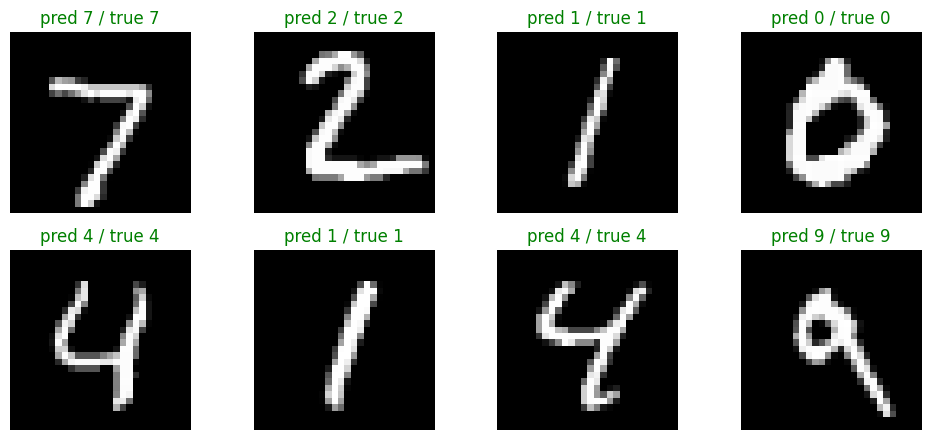

In [53]:
import matplotlib.pyplot as plt

model.eval()
correct = 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(dim=1) == y).sum().item()

acc = correct / len(test_set)
print(f"测试集准确率: {acc * 100:.2f}%")

x, y = next(iter(test_loader))
with torch.no_grad():
    pred = model(x.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 4, figsize=(10, 4.5))
for ax, img, t, p in zip(axes.flat, x, y, pred):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"pred {p.item()} / true {t.item()}",
                 color="green" if p == t else "red")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 第 7 节 · 错误样本分析

本轮 1 万张测试集上模型只错 **51 张（99.49%）**。把它们**全部筛出来集中展示**，看看"错的都是些什么牛鬼蛇神"——错误有没有规律？

**第一格 · 筛选与展示的代码逻辑：**

- **筛选**：`pred = model(x).argmax(dim=1)` 拿到每批的预测；`mask = (pred != y)` 是布尔掩码，`x[mask]` 就挑出该批所有预测错误的样本；
- **收集**：逐批把错图、预测值、真值分别存进列表；`.cpu()` 把张量从 GPU 拷回内存；
- **动态排版**：错误数 N 事先未知 → `ceil(N / 8)` 动态算行数；`axes.flatten()` 拉平子图数组，便于统一循环；多余的空格子 `axis("off")` 隐藏；
- **读图**：子图标题为 `Pred:预测 / True:真值`，红色表示这是一张错图。

**第二格 · 混淆对统计**：用 `Counter` 统计"真值 → 预测"的频次，把肉眼看到的规律变成硬数字。

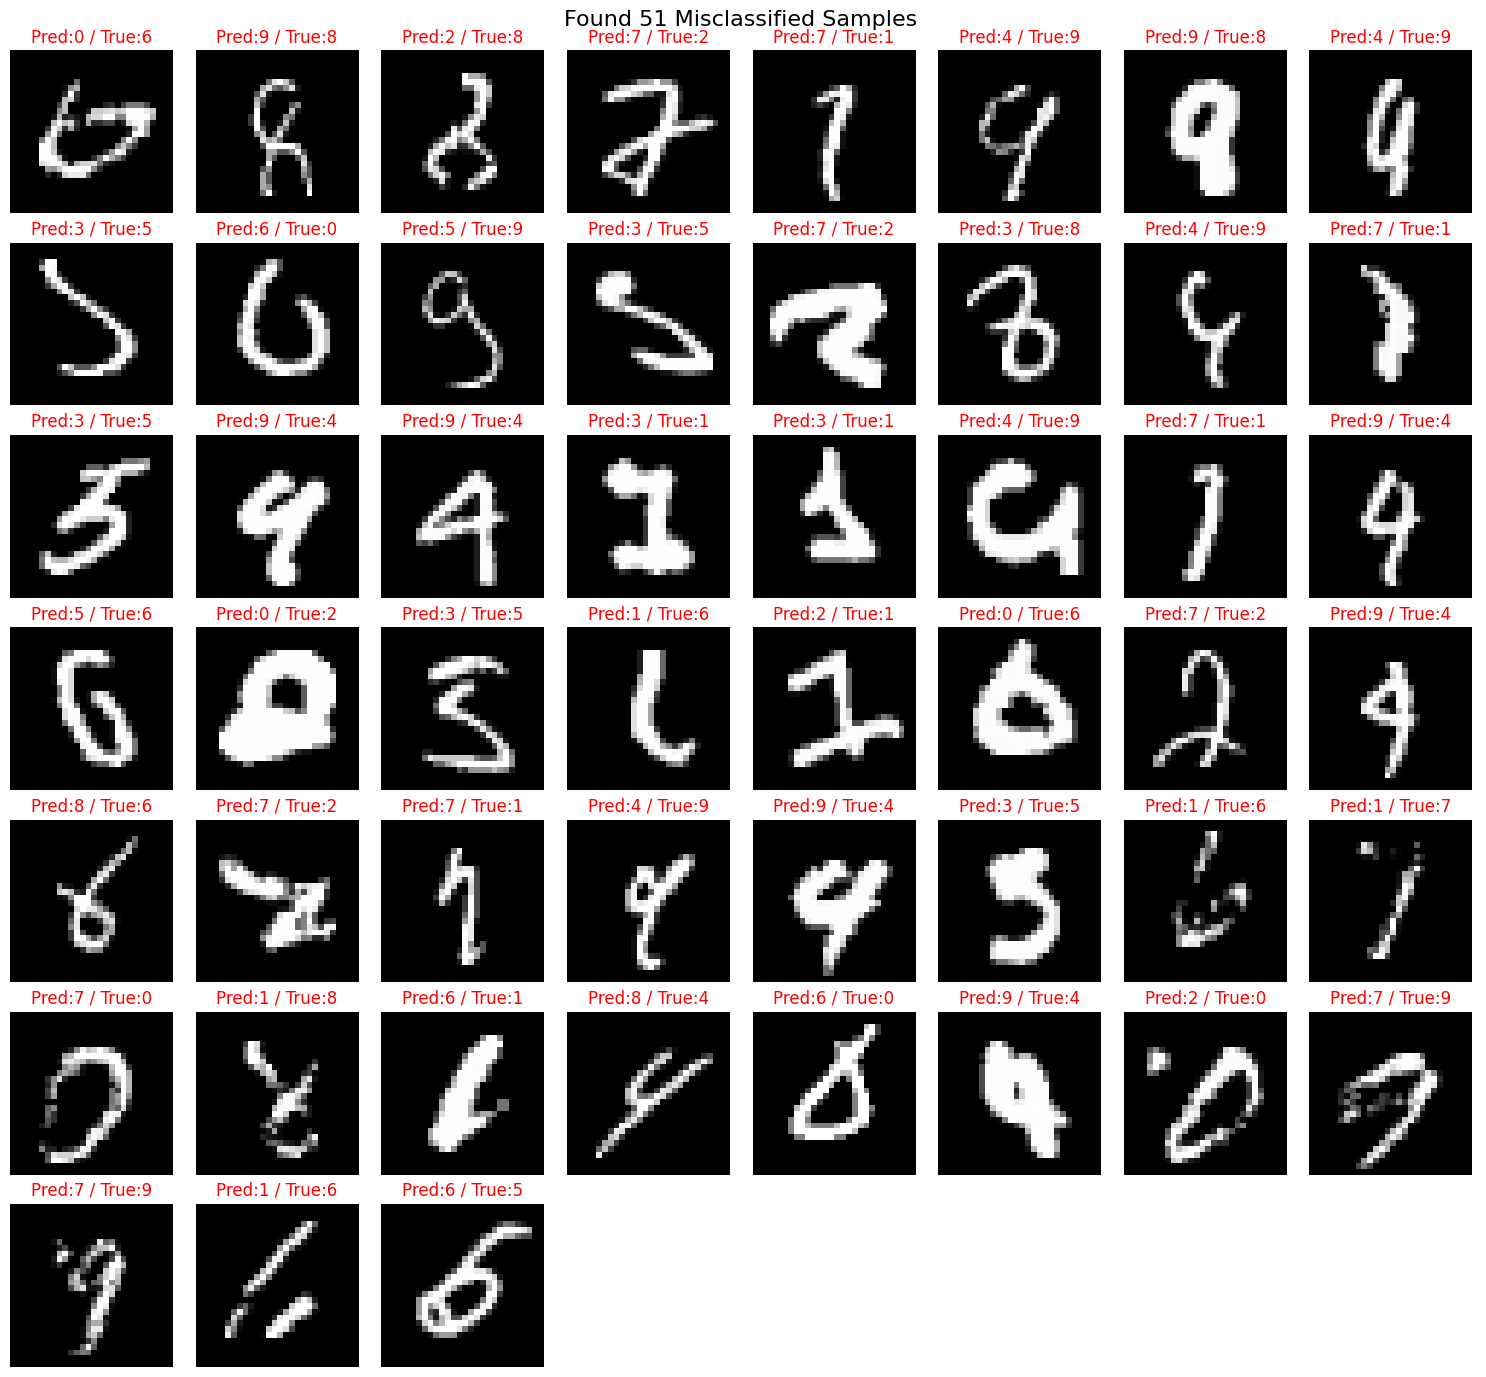

In [54]:
model.eval()
wrong_imgs, wrong_preds, wrong_trues = [], [], []

# 1. 遍历整个测试集，收集所有预测错误的样本
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)

        # 找出当前 batch 中预测错误的索引
        mask = (pred != y)

        # 如果有错误样本，就把它们挑出来
        if mask.any():
            wrong_imgs.extend(x[mask].cpu())
            wrong_preds.extend(pred[mask].cpu())
            wrong_trues.extend(y[mask].cpu())

# 2. 动态计算需要多少行子图（每行显示 8 张）
num_errors = len(wrong_imgs)
num_cols = 8
num_rows = (num_errors + num_cols - 1) // num_cols  # 向上取整

# 3. 集中展示所有错误样本
if num_errors > 0:
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 2 * num_rows))
    # 将 axes 展平，方便统一循环（兼容单行和多行的情况）
    axes = axes.flatten() if num_rows > 1 else axes

    for ax, img, t, p in zip(axes, wrong_imgs, wrong_trues, wrong_preds):
        ax.imshow(img.squeeze(), cmap="gray")
        ax.set_title(f"Pred:{p.item()} / True:{t.item()}", color="red")
        ax.axis("off")

    # 隐藏多余的空白子图（如果最后一行没填满 8 张）
    for i in range(num_errors, len(axes)):
        axes[i].axis("off")

    plt.suptitle(f"Found {num_errors} Misclassified Samples", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("🎉 完美！测试集中没有任何预测错误的样本！")

In [55]:
from collections import Counter

# 1. 统计"真值 → 预测"混淆对的频次
pair_counts = Counter(zip([t.item() for t in wrong_trues], [p.item() for p in wrong_preds]))

total = sum(pair_counts.values())
print(f"错误总数: {total} / 10000 = {total / 100:.2f}%\n")

print("混淆对排行（真值 → 预测）:")
for (true, pred), n in pair_counts.most_common():
    print(f"  {true} → {pred}: {n} 张")

# 2. 双向合并成"族"：4→9 与 9→4 算同一族
family_counts = Counter()
for (true, pred), n in pair_counts.items():
    family_counts[tuple(sorted((true, pred)))] += n

print("\n合并双向后的混淆族:")
for (a, b), n in family_counts.most_common():
    print(f"  {a} ↔ {b}: {n} 张")

错误总数: 51 / 10000 = 0.51%

混淆对排行（真值 → 预测）:
  4 → 9: 6 张
  9 → 4: 5 张
  5 → 3: 5 张
  2 → 7: 4 张
  1 → 7: 4 张
  6 → 1: 3 张
  6 → 0: 2 张
  8 → 9: 2 张
  0 → 6: 2 张
  1 → 3: 2 张
  9 → 7: 2 张
  8 → 2: 1 张
  9 → 5: 1 张
  8 → 3: 1 张
  6 → 5: 1 张
  2 → 0: 1 张
  1 → 2: 1 张
  6 → 8: 1 张
  7 → 1: 1 张
  0 → 7: 1 张
  8 → 1: 1 张
  1 → 6: 1 张
  4 → 8: 1 张
  0 → 2: 1 张
  5 → 6: 1 张

合并双向后的混淆族:
  4 ↔ 9: 11 张
  1 ↔ 7: 5 张
  3 ↔ 5: 5 张
  0 ↔ 6: 4 张
  2 ↔ 7: 4 张
  1 ↔ 6: 4 张
  8 ↔ 9: 2 张
  1 ↔ 3: 2 张
  5 ↔ 6: 2 张
  0 ↔ 2: 2 张
  7 ↔ 9: 2 张
  2 ↔ 8: 1 张
  5 ↔ 9: 1 张
  3 ↔ 8: 1 张
  1 ↔ 2: 1 张
  6 ↔ 8: 1 张
  0 ↔ 7: 1 张
  1 ↔ 8: 1 张
  4 ↔ 8: 1 张


**本轮 51 张错误的"族谱"**（数字来自上一格的统计，形态来自逐张读图）：

| 混淆族 | 张数 | 典型长相 |
|--------|:---:|----------|
| **4 ↔ 9** | 11 | 顶部闭口的 4 像 9；开口的 9 像 4 —— 最大宗 |
| **6 的变形**（↔ 0/1/5/8） | 11 | 圈太大 → 像 0；圈没闭合 → 像 5；只剩一斜杠 → 像 1；上钩太长 → 像 8 |
| **带帽的 1**（↔ 7/3/2/8） | 9 | 长帽的 1 ↔ 7；帽太长/带钩 → 被读成 3、2；断笔的 8 → 被读成 1 |
| **快写的 5**（↔ 3/9） | 6 | 顶横写平、下圈残缺 → 只剩折线像 3；9 的直线写法 → 像 5 |
| **开口的 8**（↔ 9/2/3/4） | 5 | 上圈开口 → 像 9；写扁/写斜 → 像 2、3；连笔 → 像 8 |
| **棱角 2 ↔ 7** | 4 | 2 写成硬折线，只剩"7 的骨架" |
| **其他** | 5 | 9 的折线写法 ↔ 7；糊成团/带斜杠的 0 |

**两个结论：**

1. 错误高度**成族**：4/9、3/5、1/7、8/3 正是公开 MNIST 错误分析里的知名易混族——模型错得很"人类"，不是你的模型有什么怪癖；
2. 其中不少错图**连人也要犹豫**（个别甚至像标注本身有问题）——所以 **99.5% 附近是这套架构的"天花板"**：再往下压错误，压的其实是数据自身的歧义，而不是模型能力。

> 注：重跑训练后这 51 张会换掉一部分（单次运行有 ±0.1~0.2% 的抖动），但"族"的结构基本不变——这正是结构性规律的体现。

## 附 · 备份权重到 Google Drive

`/content` 里的文件在 runtime 回收后会清空 —— 训练出满意的模型后，运行下面这格把权重备份到 Drive 的 `MyDrive/mnist_weights/`：

- 首次运行会弹出 Google Drive 授权对话框，选择账号并点「允许」；
- 以后重新训练出新模型，再跑一次这格即可覆盖更新。

In [50]:
from google.colab import drive
drive.mount("/content/drive")

import os, shutil
dst = "/content/drive/MyDrive/mnist_weights"
os.makedirs(dst, exist_ok=True)
for f in ["best_model.pt", "best_model_dropout.pt", "best_model_no_dropout.pt", "model_13ep.pt"]:
    shutil.copy(f"/content/{f}", os.path.join(dst, f))
print("已备份到 Drive:", dst)
for f in sorted(os.listdir(dst)):
    print(" ", f, f"{os.path.getsize(os.path.join(dst, f)) / 1e6:.2f} MB")

Mounted at /content/drive
已备份到 Drive: /content/drive/MyDrive/mnist_weights
  best_model.pt 1.69 MB
  best_model_dropout.pt 1.69 MB
  best_model_no_dropout.pt 1.69 MB
  model_13ep.pt 1.69 MB


## 附 2 · 保存错误样本汇总图（可选）

把「第 7 节」筛出的 51 张错误样本渲染成一张汇总大图并保存为文件：

- Colab VM：`/content/mnist_errors/mnist_errors_grid.png`；
- 若 Drive 已挂载（先跑过上一节），自动备份到 `MyDrive/mnist_errors/`；
- 以后重新训练后，重跑本格即可更新图片。

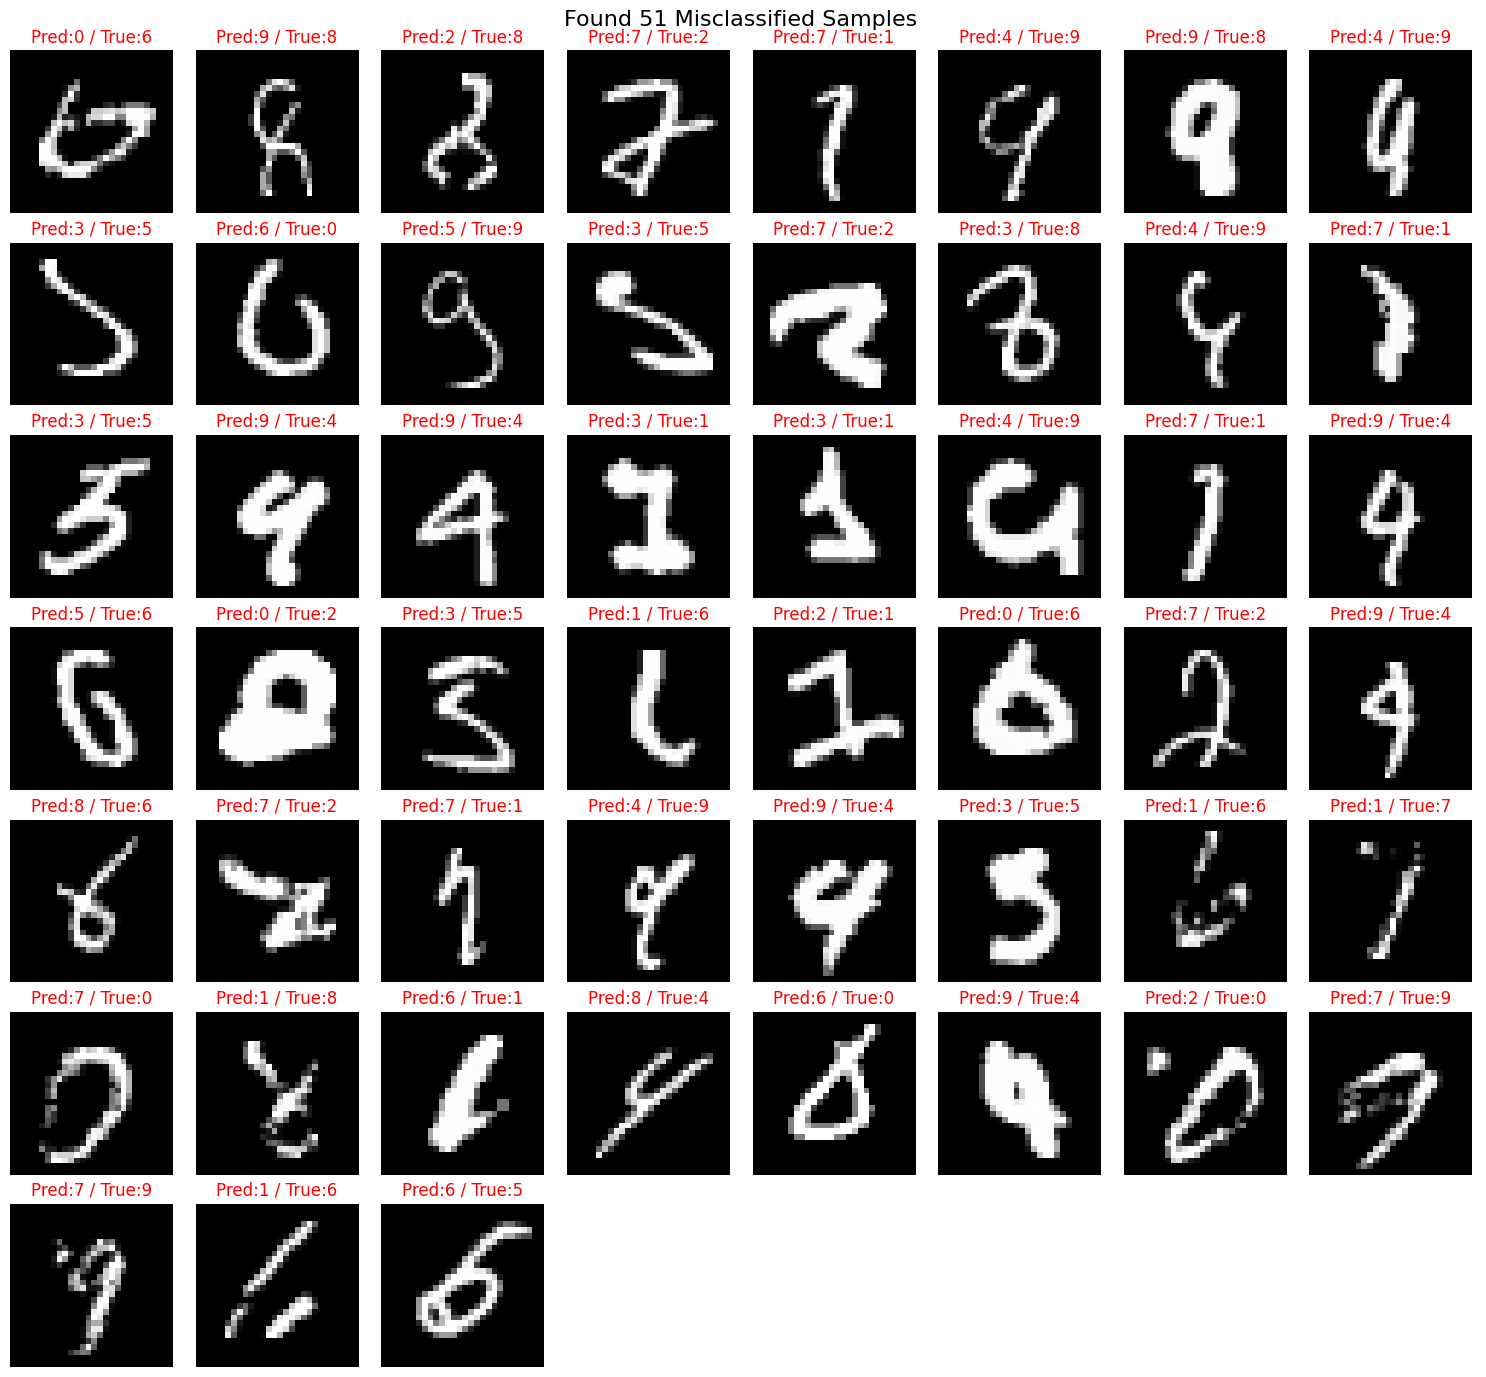

已保存: /content/mnist_errors/mnist_errors_grid.png
已备份到 Drive: /content/drive/MyDrive/mnist_errors


In [56]:
import os, shutil

# 重新渲染"51 张全家福"并存为文件（不依赖展示格的窗口状态）
os.makedirs("/content/mnist_errors", exist_ok=True)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 2 * num_rows))
axes = axes.flatten() if num_rows > 1 else axes
for ax, img, t, p in zip(axes, wrong_imgs, wrong_trues, wrong_preds):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Pred:{p.item()} / True:{t.item()}", color="red")
    ax.axis("off")
for i in range(num_errors, len(axes)):
    axes[i].axis("off")
plt.suptitle(f"Found {num_errors} Misclassified Samples", fontsize=16)
plt.tight_layout()

grid_path = "/content/mnist_errors/mnist_errors_grid.png"
fig.savefig(grid_path, dpi=120, bbox_inches="tight")
plt.show()
print("已保存:", grid_path)

# 若 Drive 已挂载（先跑过「附 · 备份权重」一节），顺手备份一份
if os.path.exists("/content/drive/MyDrive"):
    dst = "/content/drive/MyDrive/mnist_errors"
    os.makedirs(dst, exist_ok=True)
    shutil.copy(grid_path, os.path.join(dst, "mnist_errors_grid.png"))
    print("已备份到 Drive:", dst)
else:
    print("（Drive 未挂载，跳过备份）")